# TCC — Reconhecimento de Caracteres Japoneses com CNN

Notebook de treinamento de uma rede neural convolucional (CNN) para classificação de caracteres japoneses (hiragana, katakana e kanji). O modelo treinado é exportado para o formato ONNX e utilizado na API de inferência do projeto KanjiScan.

**Dataset:** 195.227 imagens, 215 classes  
**Arquitetura:** CNN com 3 blocos Conv→ReLU→MaxPool + classificador com Dropout  
**Acurácia final (teste):** 98,6%

---

In [ ]:
!unzip /content/drive/MyDrive/TCC/dataset_processed.zip -d /content

A saída de streaming foi truncada nas últimas 5000 linhas.
 extracting: /content/content/dataset_processed/images/ヨ/ETL6_103_00674.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL6_103_01061.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL6_103_00056.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL1_88_00394.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL1_88_00825.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL1_88_00880.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL6_103_00013.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL1_88_00335.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL6_103_00247.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL1_88_00130.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL1_88_01184.jpg  
 extracting: /content/content/dataset_processed/images/ヨ/ETL6_103_00262.jpg  
 extracting

In [ ]:
!pip install -U sympy
!pip install -U torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/

In [ ]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 20.2 MB/s eta 0:00:00


## 1. Imports e Configurações Gerais

Carregamento das bibliotecas principais e definição dos hiperparâmetros globais do experimento.

- `IMG_SIZE`: resolução de entrada das imagens (64×64 px)
- `BATCH_SIZE`: número de amostras por iteração de treino
- `SEED`: semente para reprodutibilidade da divisão do dataset
- `device`: usa GPU (CUDA) se disponível, caso contrário CPU

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

DATASET_DIR = "/content/content/dataset_processed/images"

BATCH_SIZE = 64
IMG_SIZE = (64, 64)
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## 2. Pipeline de Transformações

Transformações aplicadas a cada imagem antes de ser passada ao modelo:

1. **Grayscale** — converte para escala de cinza (1 canal), compatível com a entrada da CNN e reduz dimensionalidade
2. **Resize** — redimensiona para 64×64 pixels
3. **ToTensor** — converte de PIL Image para tensor PyTorch no intervalo [0, 1]

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

### Carregamento do Dataset

`ImageFolder` lê o dataset assumindo que cada subdiretório dentro de `DATASET_DIR` corresponde a uma classe. Os nomes dos subdiretórios se tornam os rótulos das classes — neste caso, os próprios caracteres japoneses.

In [ ]:
dataset = datasets.ImageFolder(
    root=DATASET_DIR,
    transform=transform
)

num_classes = len(dataset.classes)

print("Total de imagens:", len(dataset))
print("Total de classes:", num_classes)
print(dataset.classes[:10])

Total de imagens: 195227
Total de classes: 215
['あ', 'い', 'う', 'え', 'お', 'か', 'が', 'き', 'ぎ', 'く']


### Divisão em Treino, Validação e Teste

O dataset é dividido aleatoriamente em três partições com semente fixa para garantir reprodutibilidade:

| Partição | Proporção | Finalidade |
|---|---|---|
| Treino | 70% | Atualização dos pesos do modelo |
| Validação | 15% | Monitoramento do overfitting durante o treino |
| Teste | 15% | Avaliação final imparcial após o treino |

In [ ]:
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

### Criação dos DataLoaders

Encapsulam as partições e fornecem batches de forma eficiente durante o treino:

- `shuffle=True` no treino: embaralha os dados a cada época para evitar viés de ordem
- `num_workers=2`: paraleliza o carregamento de imagens para não bloquear a GPU
- `pin_memory=True`: acelera a transferência CPU→GPU ao usar memória de página fixada

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## 3. Arquitetura da CNN

A `CNNBaseline` é composta por dois blocos principais:

**Extrator de features (`features`)** — três camadas convolucionais em sequência:
- Cada bloco: `Conv2d → ReLU → MaxPool2d(2×2)`
- O número de filtros dobra a cada bloco: 32 → 64 → 128
- O `MaxPool2d` reduz as dimensões espaciais à metade; após 3 blocos: 64×64 → 8×8

**Classificador (`classifier`)** — cabeça totalmente conectada:
- `Flatten` converte o mapa de features 128×8×8 em um vetor de 8.192 elementos
- Camada linear 8.192→256 com ReLU
- `Dropout(0.4)` para regularização (desativa aleatoriamente 40% dos neurônios durante o treino)
- Camada linear 256→`num_classes` produz os logits por classe

Entrada: `[batch, 1, 64, 64]` → Saída: logits `[batch, num_classes]`

In [ ]:
class CNNBaseline(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Instanciação e Inspeção do Modelo

O modelo é criado com o número de classes detectado no dataset e movido para o device disponível (GPU/CPU). A impressão mostra a estrutura completa com todas as camadas e seus parâmetros.

In [ ]:
model = CNNBaseline(num_classes).to(device)
print(model)

CNNBaseline(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=215, bias=True)
  )
)


## 4. Função de Custo, Otimizador e Scheduler

- **CrossEntropyLoss**: combina `LogSoftmax + NLLLoss`, adequada para classificação multiclasse com logits brutos
- **Adam** (`lr=0.001`): otimizador adaptativo amplamente utilizado em deep learning; adapta a taxa de aprendizado por parâmetro
- **ReduceLROnPlateau**: reduz a LR em 50% (`factor=0.5`) quando a loss de validação não melhora por 3 épocas consecutivas (`patience=3`), evitando estagnação em platôs

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

## 5. Função de Treinamento por Época

A função `train_one_epoch` executa uma passagem completa pelo conjunto de treino:

1. `model.train()` — ativa comportamentos exclusivos do treino (ex: Dropout ativo)
2. Para cada batch: move dados para o device → zera gradientes → forward pass → calcula loss → backward (backpropagation) → atualiza pesos
3. Acumula loss e acurácia ponderadas pelo tamanho do batch
4. Retorna loss média e acurácia média da época

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### Função de Avaliação

A função `evaluate` roda o modelo em modo inferência:

- `model.eval()` — desativa camadas com comportamento diferente em treino (Dropout é desligado)
- `torch.no_grad()` — desabilita o cálculo de gradientes, economizando memória e acelerando a inferência
- Mesma lógica de acumulação de métricas que `train_one_epoch`, sem a etapa de otimização

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

## 6. Loop de Treinamento

O loop roda por até 30 épocas com duas estratégias para evitar overfitting:

- **Early stopping** (`patience=5`): interrompe o treino se a acurácia de validação não melhorar por 5 épocas consecutivas
- **Model checkpoint**: salva o modelo em disco (`best_cnn_model.pth`) sempre que a acurácia de validação supera o melhor valor registrado, garantindo que o artefato final corresponda ao melhor ponto do treino

O scheduler ajusta a taxa de aprendizado com base na loss de validação ao fim de cada época.

In [ ]:
EPOCHS = 30
best_val_acc = 0.0
patience = 5
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": dataset.classes,
            "num_classes": num_classes
        }, "best_cnn_model.pth")

        print("Modelo salvo.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping ativado.")
        break

Epoch [1/30] Train Loss: 1.3454 | Train Acc: 0.6479 Val Loss: 0.2854 | Val Acc: 0.9192
Modelo salvo.
Epoch [2/30] Train Loss: 0.4530 | Train Acc: 0.8641 Val Loss: 0.1762 | Val Acc: 0.9541
Modelo salvo.
Epoch [3/30] Train Loss: 0.3086 | Train Acc: 0.9067 Val Loss: 0.1226 | Val Acc: 0.9661
Modelo salvo.
Epoch [4/30] Train Loss: 0.2360 | Train Acc: 0.9288 Val Loss: 0.1061 | Val Acc: 0.9718
Modelo salvo.
Epoch [5/30] Train Loss: 0.1949 | Train Acc: 0.9407 Val Loss: 0.0937 | Val Acc: 0.9766
Modelo salvo.
Epoch [6/30] Train Loss: 0.1634 | Train Acc: 0.9497 Val Loss: 0.0922 | Val Acc: 0.9772
Modelo salvo.
Epoch [7/30] Train Loss: 0.1435 | Train Acc: 0.9558 Val Loss: 0.0869 | Val Acc: 0.9776
Modelo salvo.
Epoch [8/30] Train Loss: 0.1273 | Train Acc: 0.9610 Val Loss: 0.0791 | Val Acc: 0.9805
Modelo salvo.
Epoch [9/30] Train Loss: 0.1128 | Train Acc: 0.9649 Val Loss: 0.0870 | Val Acc: 0.9783
Epoch [10/30] Train Loss: 0.1028 | Train Acc: 0.9683 Val Loss: 0.0790 | Val Acc: 0.9805
Modelo salvo.
Epo

## 7. Visualização das Métricas de Treinamento

Gráficos de loss e acurácia ao longo das épocas para inspecionar a convergência do modelo. A proximidade entre as curvas de treino e validação indica ausência de overfitting significativo.

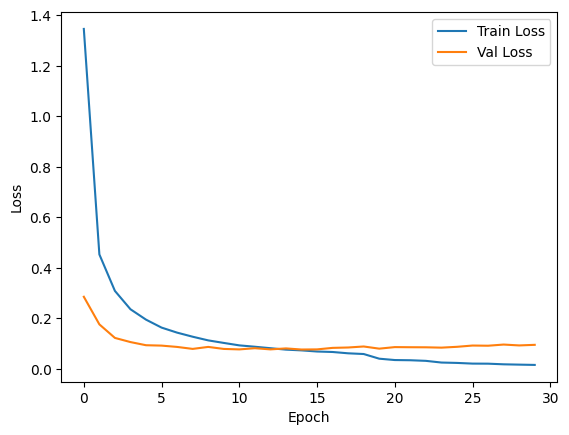

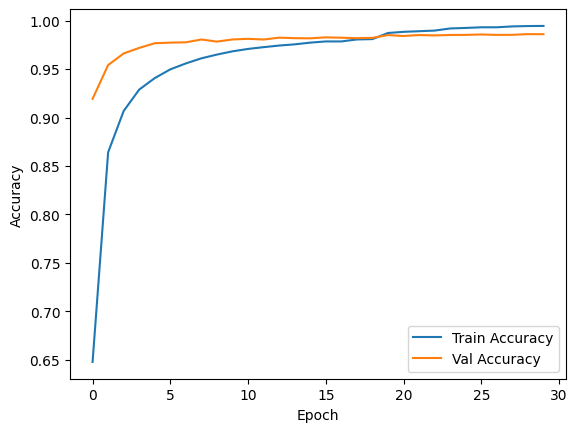

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 8. Avaliação no Conjunto de Teste

Coleta todas as predições do modelo no conjunto de teste (que não foi usado durante o treino) para calcular métricas detalhadas. As predições são armazenadas em `all_preds` e os rótulos reais em `all_labels`.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

### Relatório de Classificação por Classe

O `classification_report` exibe precisão, recall e F1-score para cada uma das 215 classes, além das médias macro e ponderada. Permite identificar classes com performance individual abaixo da média.

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes,
    digits=4
))

              precision    recall  f1-score   support

           あ     1.0000    1.0000    1.0000        47
           い     1.0000    1.0000    1.0000        62
           う     0.9808    0.9273    0.9533        55
           え     0.9833    1.0000    0.9916        59
           お     0.9833    0.9672    0.9752        61
           か     0.9815    1.0000    0.9907        53
           が     0.9821    0.9821    0.9821        56
           き     0.9831    1.0000    0.9915        58
           ぎ     1.0000    0.9412    0.9697        34
           く     0.9839    1.0000    0.9919        61
           ぐ     0.9808    1.0000    0.9903        51
           け     0.9661    0.9828    0.9744        58
           げ     1.0000    1.0000    1.0000        56
           こ     0.9661    0.9500    0.9580        60
           ご     1.0000    1.0000    1.0000        55
           さ     0.9868    0.9868    0.9868        76
           ざ     0.9273    1.0000    0.9623        51
           し     0.9773    

### Matriz de Confusão

A matriz de confusão (215×215) mostra a distribuição das predições: a diagonal representa acertos e os valores fora dela indicam erros. O mapa de calor facilita a identificação de pares de caracteres frequentemente confundidos entre si.

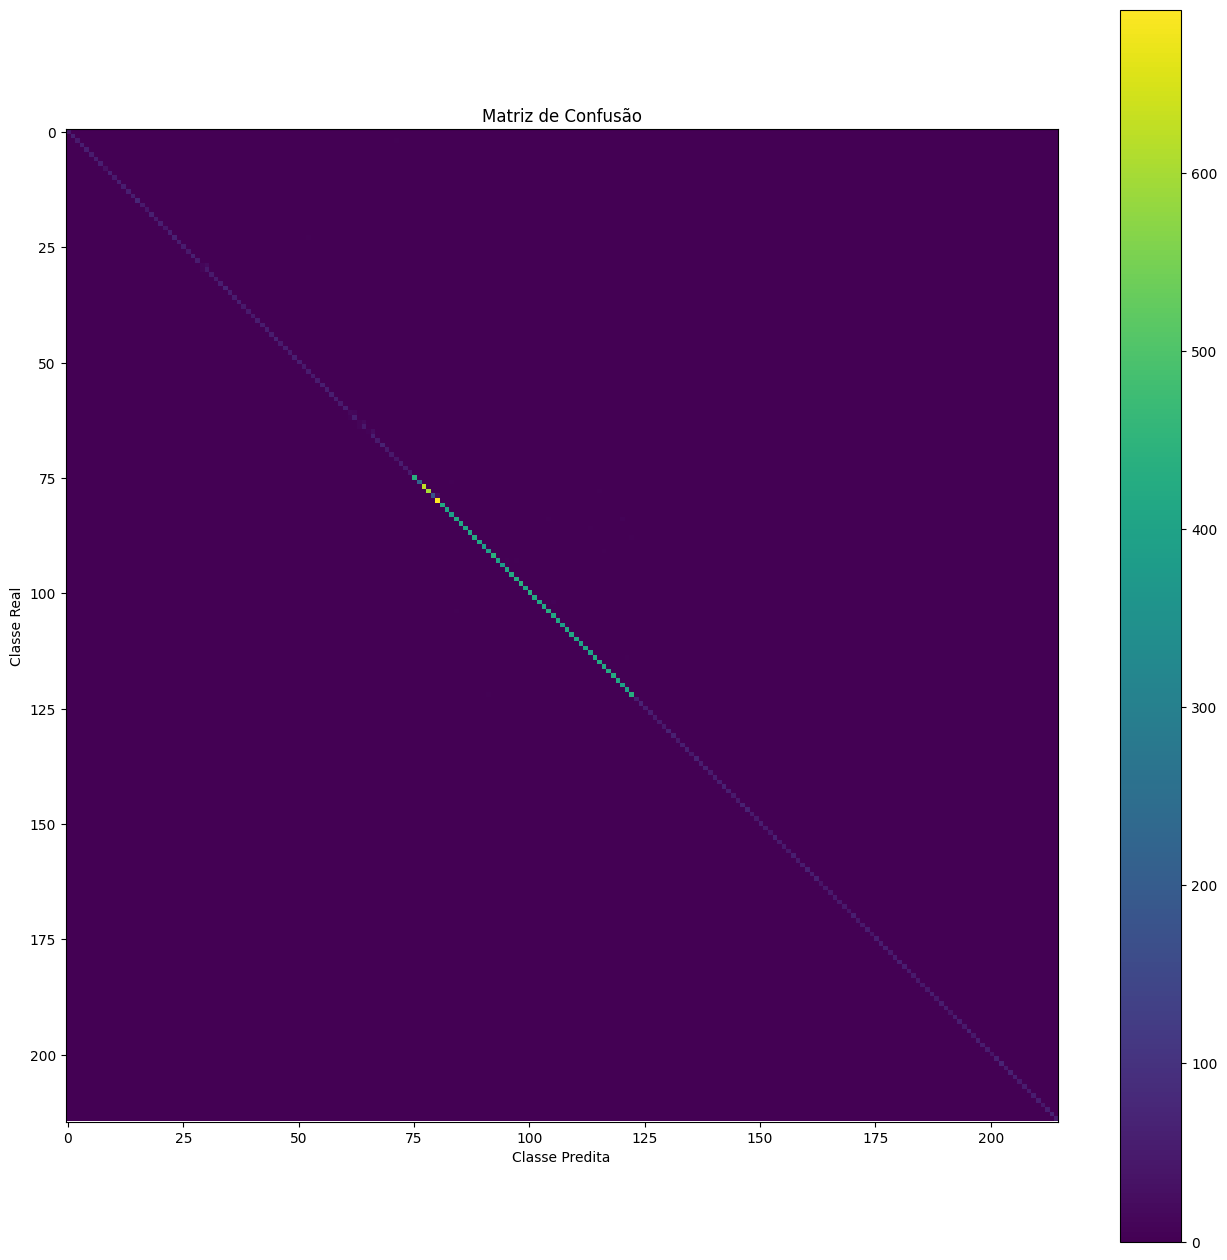

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 16))
plt.imshow(cm)
plt.title("Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.colorbar()
plt.show()

### Análise dos Principais Erros de Classificação

Lista ordenada dos pares (real → predito) com maior número de confusões. Os erros mais frequentes ocorrem entre versões grandes e pequenas do mesmo caractere (ex: `よ`/`ょ`, `つ`/`っ`, `ゆ`/`ゅ`), o que é esperado dado que esses pares são visualmente quase idênticos em 64×64 px.

In [ ]:
errors = []

for true_idx in range(len(cm)):
    for pred_idx in range(len(cm)):
        if true_idx != pred_idx and cm[true_idx][pred_idx] > 0:
            errors.append((
                dataset.classes[true_idx],
                dataset.classes[pred_idx],
                cm[true_idx][pred_idx]
            ))

errors = sorted(errors, key=lambda x: x[2], reverse=True)

for true_class, pred_class, count in errors[:430]:
    print(f"Real: {true_class} | Predito: {pred_class} | Erros: {count}")

Real: ょ | Predito: よ | Erros: 22
Real: ェ | Predito: エ | Erros: 20
Real: っ | Predito: つ | Erros: 19
Real: ゅ | Predito: ゆ | Erros: 18
Real: ゃ | Predito: や | Erros: 13
Real: つ | Predito: っ | Erros: 9
Real: ゆ | Predito: ゅ | Erros: 9
Real: や | Predito: ゃ | Erros: 6
Real: ク | Predito: ワ | Erros: 6
Real: ハ | Predito: ヘ | Erros: 6
Real: ク | Predito: フ | Erros: 5
Real: コ | Predito: ユ | Erros: 5
Real: ソ | Predito: リ | Erros: 4
Real: チ | Predito: ナ | Erros: 4
Real: フ | Predito: ク | Erros: 4
Real: ヨ | Predito: ヲ | Erros: 4
Real: う | Predito: ろ | Erros: 3
Real: そ | Predito: ぺ | Erros: 3
Real: ィ | Predito: キ | Erros: 3
Real: ウ | Predito: ラ | Erros: 3
Real: シ | Predito: ン | Erros: 3
Real: チ | Predito: テ | Erros: 3
Real: ン | Predito: ソ | Erros: 3
Real: ぎ | Predito: ざ | Erros: 2
Real: ぜ | Predito: せ | Erros: 2
Real: よ | Predito: ょ | Erros: 2
Real: る | Predito: ろ | Erros: 2
Real: エ | Predito: ナ | Erros: 2
Real: キ | Predito: ヤ | Erros: 2
Real: サ | Predito: ナ | Erros: 2
Real: シ | Predito: ツ | Erros: 2
Rea

## 9. Avaliação com o Melhor Modelo Salvo

Carrega o checkpoint salvo durante o treinamento (`best_cnn_model.pth`) e recalcula as métricas no conjunto de teste, confirmando que o modelo persistido em disco é de fato o melhor da execução.

In [ ]:
checkpoint = torch.load("best_cnn_model.pth", map_location=device)

classes = checkpoint["classes"]
num_classes = checkpoint["num_classes"]

model = CNNBaseline(num_classes).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loss, test_acc = evaluate(
    model, test_loader, criterion, device
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.0859378524905889
Test Accuracy: 0.986136247225542


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes,
    digits=4
))

              precision    recall  f1-score   support

           あ     1.0000    1.0000    1.0000        47
           い     1.0000    1.0000    1.0000        62
           う     0.9808    0.9273    0.9533        55
           え     0.9833    1.0000    0.9916        59
           お     0.9833    0.9672    0.9752        61
           か     0.9815    1.0000    0.9907        53
           が     0.9821    0.9821    0.9821        56
           き     0.9831    1.0000    0.9915        58
           ぎ     1.0000    0.9412    0.9697        34
           く     0.9839    1.0000    0.9919        61
           ぐ     0.9808    1.0000    0.9903        51
           け     0.9661    0.9828    0.9744        58
           げ     1.0000    1.0000    1.0000        56
           こ     0.9661    0.9500    0.9580        60
           ご     1.0000    1.0000    1.0000        55
           さ     0.9868    0.9868    0.9868        76
           ざ     0.9273    1.0000    0.9623        51
           し     0.9773    

## 10. Exportação para ONNX

O modelo PyTorch é exportado para o formato ONNX (Open Neural Network Exchange), que permite inferência em runtimes otimizados como o `onnxruntime`, independente do framework de treinamento.

- `opset_version=11`: versão do conjunto de operações ONNX (o exporter pode elevar automaticamente para a versão mínima suportada)
- `do_constant_folding=True`: otimização aplicada na exportação (elimina subgrafos constantes)
- `input_names` / `output_names`: nomeia as entradas e saídas do grafo para facilitar o uso na API

In [ ]:
dummy_input = torch.randn(1, 1, 64, 64).to(device)

import torch

model.eval()

torch.onnx.export(
    model,
    dummy_input,
    "best_cnn_model.onnx",
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"]
)

print("Modelo exportado para best_cnn_model.onnx")

W0520 23:21:54.378000 600 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0520 23:21:55.327000 600 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0520 23:21:55.328000 600 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: '

[torch.onnx] Obtain model graph for `CNNBaseline([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNNBaseline([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Modelo exportado para best_cnn_model.onnx


### Validação do Grafo ONNX

Verifica a consistência estrutural do arquivo `.onnx` exportado usando o checker oficial da biblioteca `onnx`. Um modelo válido passa sem exceção.

In [ ]:
import onnx

onnx_model = onnx.load("best_cnn_model.onnx")
onnx.checker.check_model(onnx_model)

print("Modelo ONNX válido!")

Modelo ONNX válido!


## 11. Pré-processamento para Inferência (Versão 1)

Primeira versão do pipeline de pré-processamento aplicado a imagens reais (fotografadas) antes da inferência. Difere das transformações de treino pois precisa lidar com fundos variáveis, iluminação não uniforme e ruído.

A função `preprocess_image_ocr` extrai o caractere da imagem e o converte para o tensor `[1, 1, 64, 64]` esperado pela CNN.

> **Limitação desta versão:** usa threshold simples baseado em média e desvio padrão do array, sensível a variações de iluminação. Substituída pela v2 que usa a limiarização de Otsu.

In [ ]:
from PIL import Image, ImageOps, ImageFilter
import numpy as np
import torch
import matplotlib.pyplot as plt

IMG_SIZE = 64

def preprocess_image_ocr(image_path, show=False):
    # 1. Abrir e converter para grayscale
    img = Image.open(image_path).convert("L")

    # 2. Suavização leve
    img = img.filter(ImageFilter.GaussianBlur(radius=0.5))

    arr = np.array(img)

    # 3. Threshold simples
    # Pixels mais escuros que o fundo viram traço
    threshold = arr.mean() - arr.std() * 0.5
    mask = arr < threshold

    # 4. Bounding box do caractere
    coords = np.argwhere(mask)

    if coords.size == 0:
        raise ValueError("Nenhum traço detectado na imagem.")

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)

    # 5. Adicionar margem no crop
    margin = 20
    h, w = arr.shape

    x0 = max(x0 - margin, 0)
    y0 = max(y0 - margin, 0)
    x1 = min(x1 + margin, w - 1)
    y1 = min(y1 + margin, h - 1)

    cropped = img.crop((x0, y0, x1 + 1, y1 + 1))

    # 6. Binarizar crop
    crop_arr = np.array(cropped)
    threshold_crop = crop_arr.mean() - crop_arr.std() * 0.5
    binary = crop_arr < threshold_crop

    # 7. Converter para fundo preto + traço branco
    binary_img = Image.fromarray((binary * 255).astype(np.uint8), mode="L")

    # 8. Padding para deixar quadrado
    w, h = binary_img.size
    max_side = max(w, h)

    square = Image.new("L", (max_side, max_side), color=0)

    padded = Image.new("L", (max_side, max_side), color=0)
    paste_x = (max_side - w) // 2
    paste_y = (max_side - h) // 2
    padded.paste(binary_img, (paste_x, paste_y))

    # 9. Padding extra para não encostar nas bordas
    extra_padding = int(max_side * 0.15)
    padded = ImageOps.expand(padded, border=extra_padding, fill=0)

    # 10. Resize final 64x64
    square.thumbnail((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

    final_canvas = Image.new("L", (IMG_SIZE, IMG_SIZE), color=0)

    paste_x = (IMG_SIZE - square.size[0]) // 2
    paste_y = (IMG_SIZE - square.size[1]) // 2

    final_canvas.paste(square, (paste_x, paste_y))

    final_img = final_canvas

    # 11. Converter para tensor [1, 1, 64, 64]
    final_arr = np.array(final_img).astype(np.float32) / 255.0
    tensor = torch.tensor(final_arr).unsqueeze(0).unsqueeze(0)

    if show:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap="gray")
        plt.title("Original grayscale")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(cropped, cmap="gray")
        plt.title("Crop detectado")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(final_arr, cmap="gray")
        plt.title("Final 64x64")
        plt.axis("off")

        plt.show()

        print("Tensor shape:", tensor.shape)
        print("Min:", tensor.min().item())
        print("Max:", tensor.max().item())

    return tensor

def predict_pth(image_path, model, classes, device):
    model.eval()

    tensor = preprocess_image_ocr(image_path).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        top_probs, top_idxs = torch.topk(probs, k=5)

    print("Resultado .pth:")
    for prob, idx in zip(top_probs[0], top_idxs[0]):
        print(f"{classes[idx.item()]} | confiança: {prob.item():.4f}")

### Teste de Predição com o Modelo .pth

Aplica o pipeline de pré-processamento v1 em uma imagem de teste e exibe as 5 classes com maior probabilidade (Top-5 com softmax).

In [ ]:
image_path = "/content/content/sua_imagem.jpg"

predict_pth(image_path, model, classes, device)

Resultado .pth:
ナ | confiança: 0.2767
イ | confiança: 0.2278
ノ | confiança: 0.1194
ニ | confiança: 0.1025
ヘ | confiança: 0.0584


/tmp/ipykernel_600/1495725204.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  binary_img = Image.fromarray((binary * 255).astype(np.uint8), mode="L")


### Visualizando o Resultado do Pré-processamento v1

Exibe a imagem em cada etapa do pipeline: grayscale original → crop do caractere detectado → imagem final 64×64 normalizada. Útil para depurar problemas de segmentação.

Shape: (64, 64)
Min: 0.0
Max: 0.0


/tmp/ipykernel_600/1495725204.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  binary_img = Image.fromarray((binary * 255).astype(np.uint8), mode="L")


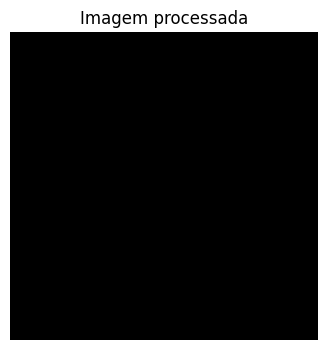

In [ ]:
import matplotlib.pyplot as plt

def show_processed_image(image_path):
    tensor = preprocess_image_ocr(image_path)

    # remover batch dimension
    img = tensor.squeeze(0).squeeze(0).numpy()

    print("Shape:", img.shape)
    print("Min:", img.min())
    print("Max:", img.max())

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title("Imagem processada")
    plt.axis("off")
    plt.show()

show_processed_image("/content/content/sua_imagem.jpg")

## 12. Limiarização de Otsu (Implementação Manual)

Implementação do algoritmo de **limiarização de Otsu**: encontra automaticamente o threshold binário ótimo maximizando a variância entre o fundo e o objeto (caractere). É mais robusto que um threshold fixo para imagens com iluminação variável.

O algoritmo percorre todos os 256 níveis de cinza possíveis e escolhe aquele que maximiza a variância inter-classes (entre os pixels abaixo e acima do threshold).

In [ ]:
from scipy import ndimage

IMG_SIZE = 64

def otsu_threshold(arr):
    hist, bin_edges = np.histogram(arr.ravel(), bins=256, range=(0, 255))
    total = arr.size

    sum_total = np.dot(np.arange(256), hist)
    sum_bg = 0
    weight_bg = 0
    max_var = 0
    threshold = 0

    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0:
            continue

        weight_fg = total - weight_bg
        if weight_fg == 0:
            break

        sum_bg += t * hist[t]

        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg

        var_between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2

        if var_between > max_var:
            max_var = var_between
            threshold = t

    return threshold

### Pipeline de Pré-processamento Aprimorado (Versão 2)

Versão melhorada com etapas adicionais de robustez para imagens reais:

1. Grayscale + suavização gaussiana leve (reduz ruído de alta frequência)
2. **Otsu threshold** para binarização adaptativa à iluminação
3. **Fechamento morfológico** — une fragmentos de traços próximos com uma janela 2×2
4. **Análise de componentes conectados** — descarta componentes com menos de 8% da área do maior (remoção de ruído isolado)
5. Crop pelo bounding box com margem de 8 px + canvas quadrado + padding de 12%
6. Resize para 64×64 com centralização e rebinarização pós-resize (threshold em 40)
7. Tensor float `[1, 1, 64, 64]`

Este pipeline é a base do pré-processamento utilizado na API (`src/services/image_processing.py`).

In [ ]:
def preprocess_image_ocr_v2(image_path, show=False):
    # 1. Abrir imagem em grayscale
    img = Image.open(image_path).convert("L")

    # 2. Suavização leve
    img = img.filter(ImageFilter.GaussianBlur(radius=0.7))

    arr = np.array(img).astype(np.uint8)

    # 3. Otsu threshold
    threshold = otsu_threshold(arr)

    # Como a foto é papel claro + escrita escura:
    # pixels escuros viram traço
    mask = arr < threshold

    # 4. Remover pequenos ruído

    # 5. Fechar pequenas falhas nos traços
    mask = ndimage.binary_closing(mask, structure=np.ones((2, 2)))

    # 6. Encontrar componentes conectados
    labeled, num_features = ndimage.label(mask)

    if num_features == 0:
        raise ValueError("Nenhum traço detectado.")

    # 7. Manter apenas o maior componente/área relevante
    objects = ndimage.find_objects(labeled)

    areas = []
    for i, obj in enumerate(objects, start=1):
        if obj is None:
            areas.append(0)
            continue

        component = labeled[obj] == i
        areas.append(component.sum())

    largest_label = np.argmax(areas) + 1

    # Em vez de pegar só um componente, pegamos todos os componentes grandes
    # porque kanjis podem ter traços separados
    area_threshold = max(20, max(areas) * 0.08)

    clean_mask = np.zeros_like(mask, dtype=bool)

    for i, area in enumerate(areas, start=1):
        if area >= area_threshold:
            clean_mask[labeled == i] = True

    # 8. Bounding box do caractere limpo
    coords = np.argwhere(clean_mask)

    if coords.size == 0:
        raise ValueError("Nenhum caractere detectado após limpeza.")

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)

    # 9. Crop mais justo com pequena margem
    margin = 8
    h, w = clean_mask.shape

    x0 = max(x0 - margin, 0)
    y0 = max(y0 - margin, 0)
    x1 = min(x1 + margin, w - 1)
    y1 = min(y1 + margin, h - 1)

    cropped_mask = clean_mask[y0:y1 + 1, x0:x1 + 1]

    # 10. Fundo preto + caractere branco
    binary_img = Image.fromarray((cropped_mask * 255).astype(np.uint8), mode="L")

    # 11. Padding para quadrado
    w, h = binary_img.size
    max_side = max(w, h)

    square = Image.new("L", (max_side, max_side), color=0)

    paste_x = (max_side - w) // 2
    paste_y = (max_side - h) // 2

    square.paste(binary_img, (paste_x, paste_y))

    # 12. Padding extra menor
    extra_padding = int(max_side * 0.12)
    square = ImageOps.expand(square, border=extra_padding, fill=0)

    # 13. Resize final
    square.thumbnail((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

    final_canvas = Image.new("L", (IMG_SIZE, IMG_SIZE), color=0)

    paste_x = (IMG_SIZE - square.size[0]) // 2
    paste_y = (IMG_SIZE - square.size[1]) // 2

    final_canvas.paste(square, (paste_x, paste_y))

    final_img = final_canvas

    # 14. Binarizar novamente após resize
    final_arr = np.array(final_img)
    final_arr = (final_arr > 40).astype(np.float32)

    # 15. Tensor [1, 1, 64, 64]
    tensor = torch.tensor(final_arr).unsqueeze(0).unsqueeze(0)

    if show:
        plt.figure(figsize=(14, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(img, cmap="gray")
        plt.title("Grayscale")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Otsu")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(cropped_mask, cmap="gray")
        plt.title("Crop limpo")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(final_arr, cmap="gray")
        plt.title("Final 64x64")
        plt.axis("off")

        plt.show()

        print("Threshold Otsu:", threshold)
        print("Tensor shape:", tensor.shape)
        print("Min:", tensor.min().item())
        print("Max:", tensor.max().item())

    return tensor

### Testando o Pré-processamento v2

Visualiza as etapas intermediárias: grayscale → máscara de Otsu → crop limpo (após remoção de ruído) → imagem final 64×64. O threshold de Otsu calculado é exibido para referência.

/tmp/ipykernel_600/4144399150.py:73: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  binary_img = Image.fromarray((cropped_mask * 255).astype(np.uint8), mode="L")


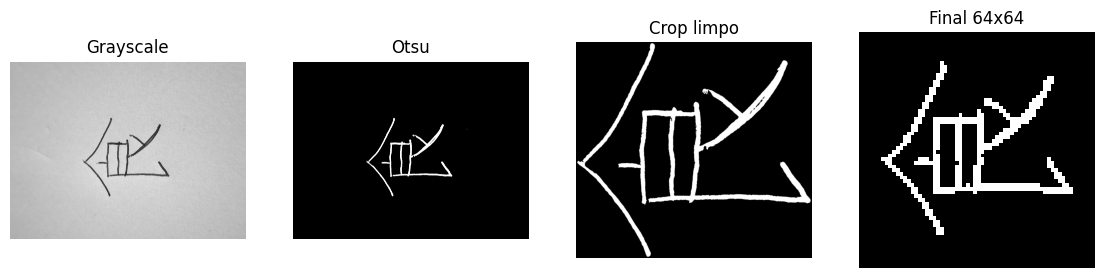

Threshold Otsu: 109
Tensor shape: torch.Size([1, 1, 64, 64])
Min: 0.0
Max: 1.0


In [ ]:
image_path = "/content/content/sua_imagem.jpg"

tensor = preprocess_image_ocr_v2(image_path, show=True)

### Predição com o Pipeline v2

Combina o pré-processamento v2 com a inferência do modelo `.pth`, exibindo as 5 classes mais prováveis e suas confianças após softmax.

/tmp/ipykernel_600/4144399150.py:73: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  binary_img = Image.fromarray((cropped_mask * 255).astype(np.uint8), mode="L")


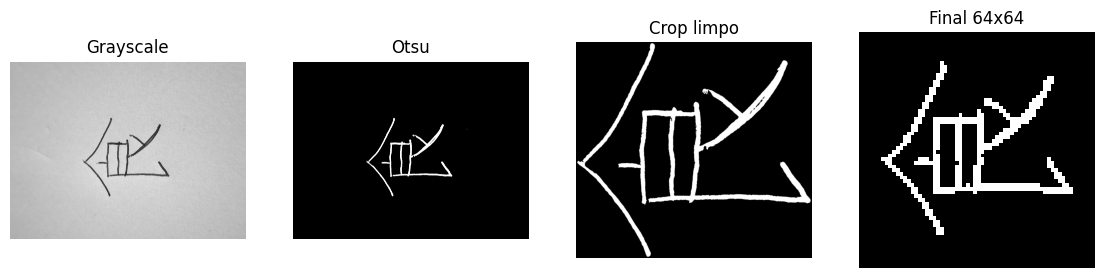

Threshold Otsu: 109
Tensor shape: torch.Size([1, 1, 64, 64])
Min: 0.0
Max: 1.0
Resultado .pth:
飲 | confiança: 0.7654
ぜ | confiança: 0.1857
め | confiança: 0.0357
ぬ | confiança: 0.0056
せ | confiança: 0.0055


In [ ]:
def predict_pth_ocr_v2(image_path, model, classes, device):
    tensor = preprocess_image_ocr_v2(image_path, show=True).to(device)

    model.eval()

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        top_probs, top_idxs = torch.topk(probs, k=5)

    print("Resultado .pth:")
    for prob, idx in zip(top_probs[0], top_idxs[0]):
        print(f"{classes[idx.item()]} | confiança: {prob.item():.4f}")

predict_pth_ocr_v2(image_path, model, classes, device)

### Predição com Rotação da Imagem

Testa a robustez do modelo a variações de orientação: rotaciona a imagem em um ângulo configurável antes do pré-processamento e exibe as predições. Útil para avaliar se a imagem precisa ser reorientada antes da inferência (ex: foto tirada de lado).

/tmp/ipykernel_600/4144399150.py:73: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  binary_img = Image.fromarray((cropped_mask * 255).astype(np.uint8), mode="L")


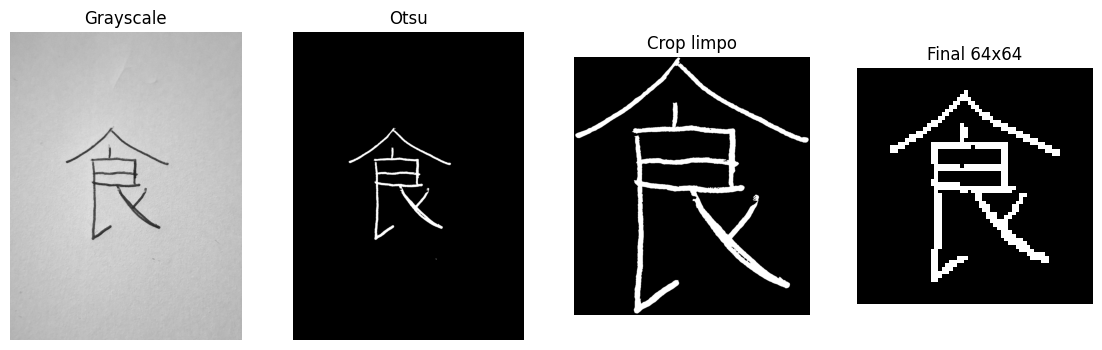

Threshold Otsu: 109
Tensor shape: torch.Size([1, 1, 64, 64])
Min: 0.0
Max: 1.0
Resultado .pth:
食 | confiança: 1.0000
室 | confiança: 0.0000
後 | confiança: 0.0000
青 | confiança: 0.0000
会 | confiança: 0.0000


In [ ]:
def predict_with_rotation(
    image_path,
    model,
    classes,
    device,
    angle=-90
):
    img = Image.open(image_path)

    rotated = img.rotate(angle, expand=True)

    temp_path = "/content/temp_rotated.png"
    rotated.save(temp_path)

    predict_pth_ocr_v2(
        temp_path,
        model,
        classes,
        device
    )

predict_with_rotation(
    image_path,
    model,
    classes,
    device,
    angle=-90
)

## 13. Download dos Artefatos Gerados

Baixa os arquivos necessários para implantar a API de inferência:

| Arquivo | Descrição |
|---|---|
| `best_cnn_model.pth` | Checkpoint PyTorch (pesos + mapeamento de classes) |
| `best_cnn_model.onnx` | Grafo de inferência ONNX |
| `best_cnn_model.onnx.data` | Pesos externos do modelo ONNX |
| `classes.json` | Lista das 215 classes (caracteres japoneses) |

In [ ]:
from google.colab import files
files.download("best_cnn_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("best_cnn_model.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("best_cnn_model.onnx.data")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

with open("classes.json", "w", encoding="utf-8") as f:
    json.dump(classes, f, ensure_ascii=False, indent=2)

files.download("classes.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>